# Pointwise, Arithmetic, and Logical Image Operations


This notebook implements context-free, pixel-level operations on digital images.


Topics include:
- Nonlinear transforms via LUT (Look-Up Table) for efficient mapping.
- Two-operand arithmetic (image fusion, frame differencing, masking) with integer overflow handling.
- Boolean algebra on binary masks.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


## 1. Look-Up Table (LUT) Operations


LUTs map pixel values nonlinearly without iterating over the full image matrix—standard for square, logarithmic, and exponential transforms.

In [2]:

!wget https://raw.githubusercontent.com/vision-agh/poc_sw/master/02_Point/lut.py
import lut 


--2026-03-18 00:15:08--  https://raw.githubusercontent.com/vision-agh/poc_sw/master/02_Point/lut.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10330 (10K) [text/plain]
Saving to: 'lut.py'

     0K ..........                                            100% 5,95M=0,002s

2026-03-18 00:15:08 (5,95 MB/s) - 'lut.py' saved [10330/10330]



Wizualizacja wybranej funkcji przekodowania (transformacja kwadratowa):

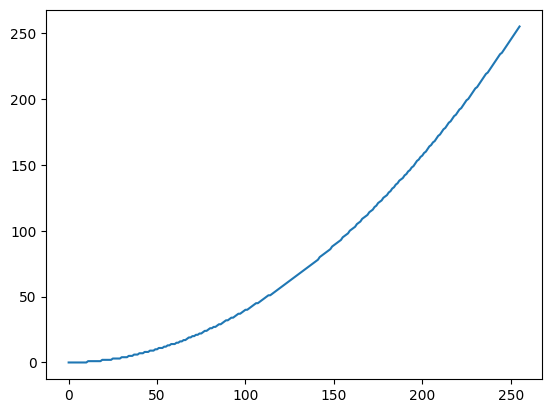

In [3]:
plt.plot(lut.kwadratowa)

Load a test image for transform evaluation.

--2026-03-18 00:15:08--  https://raw.githubusercontent.com/vision-agh/poc_sw/master/02_Point/lena.bmp
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 66616 (65K) [image/bmp]
Saving to: 'lena.bmp'

     0K .......... .......... .......... .......... .......... 76%  939K 0s
    50K .......... .....                                      100% 99,5M=0,05s

2026-03-18 00:15:09 (1,19 MB/s) - 'lena.bmp' saved [66616/66616]

--2026-03-18 00:15:09--  https://raw.githubusercontent.com/vision-agh/poc_sw/master/02_Point/jet.bmp
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awai

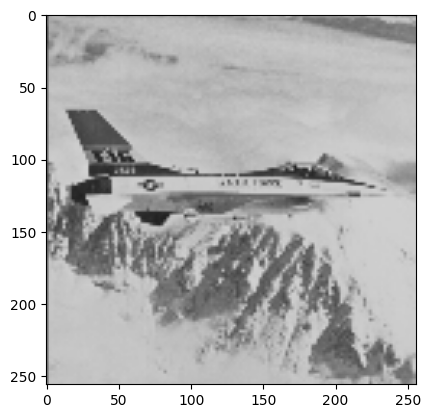

In [4]:
!wget https://raw.githubusercontent.com/vision-agh/poc_sw/master/02_Point/lena.bmp
!wget https://raw.githubusercontent.com/vision-agh/poc_sw/master/02_Point/jet.bmp
JET_IMAGE = cv2.imread('jet.bmp')
plt.imshow(JET_IMAGE)

Aplikacja transformacji odwrotnej (odpowiednik negatywu).

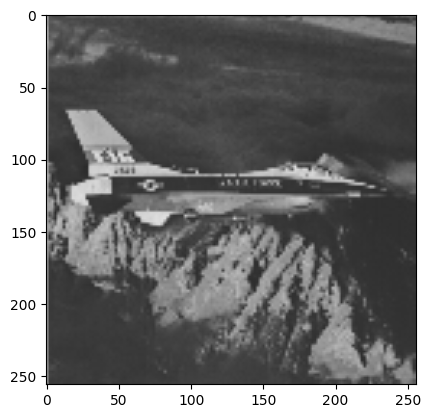

In [5]:
a = cv2.LUT(JET_IMAGE, lut.odwrotna)
plt.imshow(a)
plt.show()

### LUT Transform Visualization


A helper plots the LUT curve alongside the input and transformed images for quick validation.

In [6]:
def LUT(image, lut):
    przekodowanie = cv2.LUT(image, lut)
    ax1 = plt.subplot(1, 3, 1)
    ax1.plot(lut)
    ax1.set_title("LUT curve")
    ax1.set_aspect('equal')
    
    ax2 = plt.subplot(1, 3, 2)
    ax2.imshow(image)
    ax2.set_title("Original image")
    ax2.set_aspect('equal')

    ax3 = plt.subplot(1, 3, 3)
    ax3.imshow(przekodowanie)
    ax3.set_title("Transformed image")
    ax3.set_aspect('equal')
    plt.show()



Evaluating several LUT mappings:

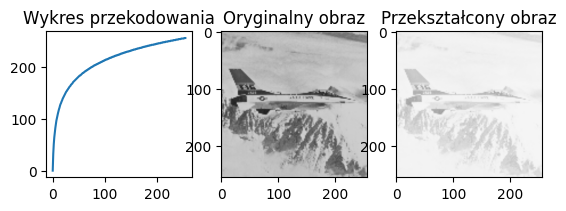

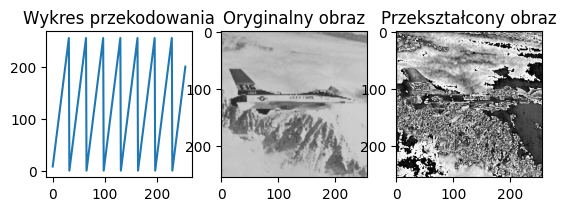

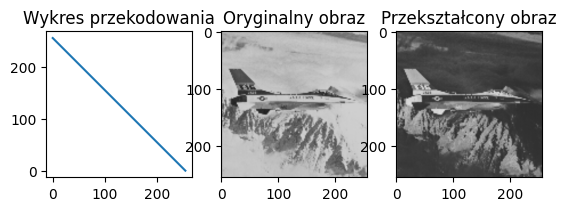

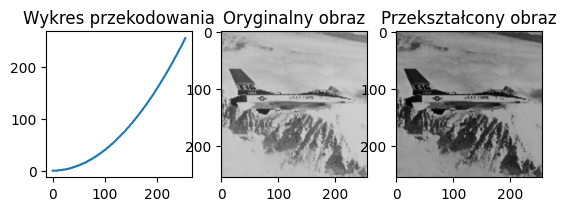

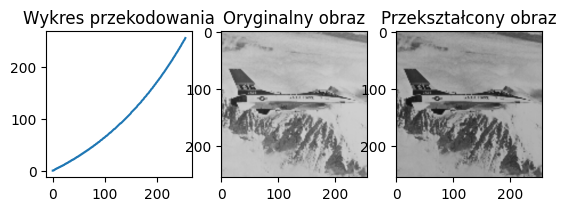

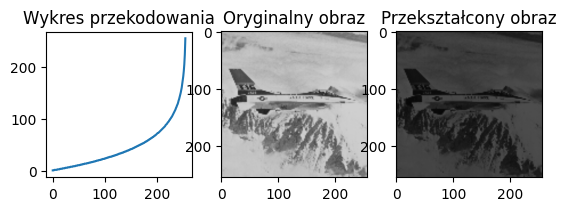

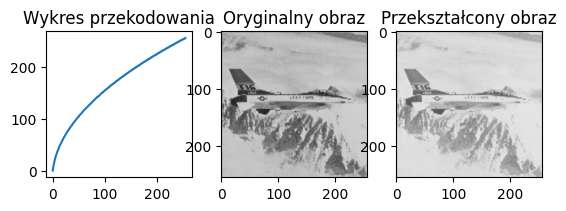

In [7]:
LUT(JET_IMAGE, lut.log)
LUT(JET_IMAGE, lut.pila)
LUT(JET_IMAGE, lut.odwrotna)
LUT(JET_IMAGE, lut.kwadratowa)
LUT(JET_IMAGE, lut.wykladnicza)
LUT(JET_IMAGE, lut.odwlog)
LUT(JET_IMAGE, lut.pierwiastkowa)


## 2. Arithmetic Operations


Two-operand matrix operations support change detection (e.g. background subtraction), blending, and selective pixel suppression.

In [8]:
Lena_IMAGE = cv2.imread('lena.bmp')
JET_IMAGE = cv2.imread('jet.bmp')

### Image Addition (Overflow)
Adding `uint8` matrices can clip values above 255 (saturation or wrap-around, depending on implementation).

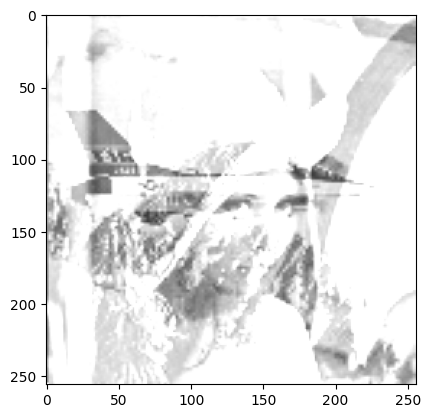

In [9]:
plt.imshow(cv2.add(Lena_IMAGE, JET_IMAGE))
plt.show()

Cast to 16-bit, perform addition safely, normalize to $[0, 255]$, then cast back to 8-bit.

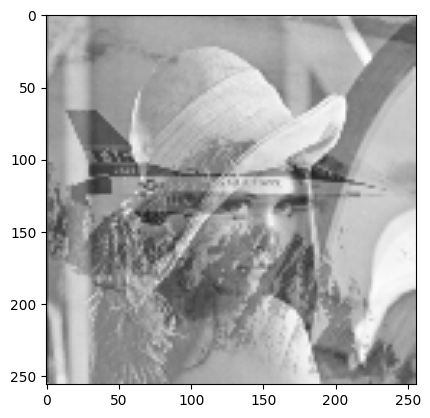

In [10]:
sum16 = JET_IMAGE.astype('uint16') + Lena_IMAGE.astype('uint16')
sum16 = (sum16 / sum16.max())* 255
sum8 = sum16.astype('uint8')
plt.imshow(sum8)

### Linear Combination (Alpha Blending)
Weighted image blending keeps the result within $[0, 255]$ by design.

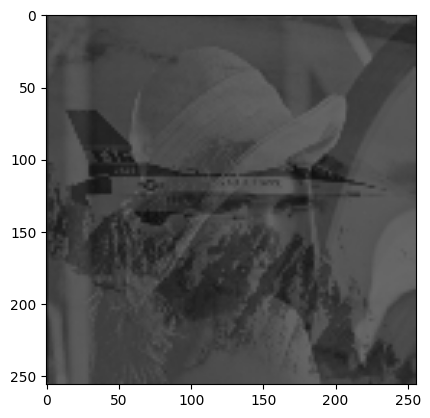

In [11]:
I = cv2.addWeighted(Lena_IMAGE, 0.2, JET_IMAGE, 0.3, 0)
plt.imshow(I)
plt.show()

### Image Subtraction
Direct matrix subtraction clips negative values to 0, which can erase detail in dark regions.

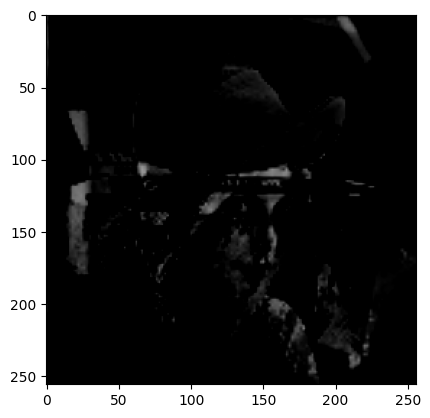

In [12]:
I = cv2.subtract(Lena_IMAGE, JET_IMAGE)
plt.imshow(I)
plt.show()


For frame differencing, take the absolute difference on signed `int16` data to avoid zero-clipping and preserve change magnitude.

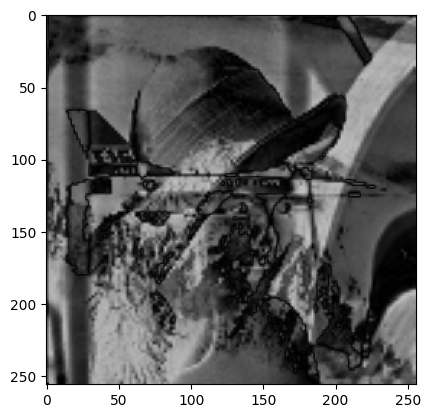

In [13]:
roznica = Lena_IMAGE.astype('int16') - JET_IMAGE.astype('int16')
roznica = np.abs(roznica)
roznica = roznica.astype('uint8')
plt.imshow(roznica)
plt.show()

### Masking (Pointwise Product)
Pixel-wise multiplication of two natural images is rarely useful on its own. The main use case is applying a binary Region of Interest (ROI) mask to isolate part of a scene.

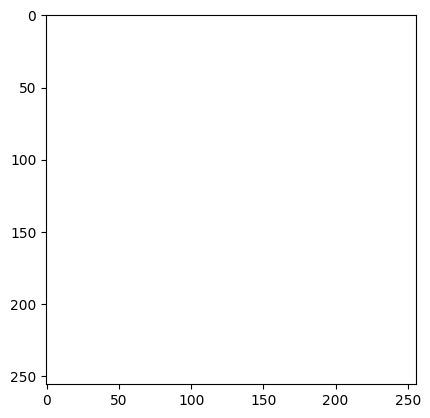

In [14]:
mnozenie = cv2.multiply(Lena_IMAGE, JET_IMAGE)
plt.imshow(mnozenie)
plt.show()

Binarize the test mask (0 or 1) and extract a circular region from the photo.

--2026-03-18 00:15:10--  https://raw.githubusercontent.com/vision-agh/poc_sw/master/02_Point/kolo.bmp
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 66614 (65K) [image/bmp]
Saving to: 'kolo.bmp'

     0K .......... .......... .......... .......... .......... 76%  990K 0s
    50K .......... .....                                      100% 16,3M=0,05s

2026-03-18 00:15:11 (1,24 MB/s) - 'kolo.bmp' saved [66614/66614]



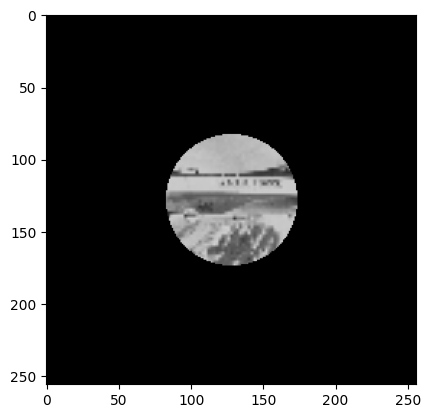

In [15]:
!wget https://raw.githubusercontent.com/vision-agh/poc_sw/master/02_Point/kolo.bmp
maska = cv2.imread('kolo.bmp')
maska= maska.astype('bool').astype('uint8')
wynik = cv2.multiply(maska, JET_IMAGE)
plt.imshow(wynik)    
plt.show()

Logical inversion (negative).

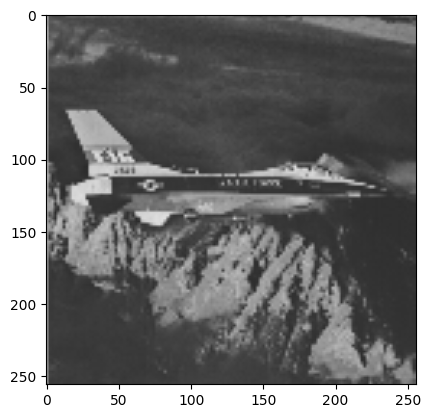

In [16]:
neg = cv2.bitwise_not(JET_IMAGE)
plt.imshow(neg)
plt.show()

## 3. Logical Operations and Boolean Algebra


Bitwise operations on binary masks are essential for composing segmentation regions—union, intersection, and exclusion.

--2026-03-18 00:15:11--  https://raw.githubusercontent.com/vision-agh/poc_sw/master/02_Point/kwadrat.bmp
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 66614 (65K) [image/bmp]
Saving to: 'kwadrat.bmp'

     0K .......... .......... .......... .......... .......... 76%  944K 0s
    50K .......... .....                                      100%  134M=0,05s

2026-03-18 00:15:11 (1,20 MB/s) - 'kwadrat.bmp' saved [66614/66614]

--2026-03-18 00:15:11--  https://raw.githubusercontent.com/vision-agh/poc_sw/master/02_Point/kolo.bmp
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request 

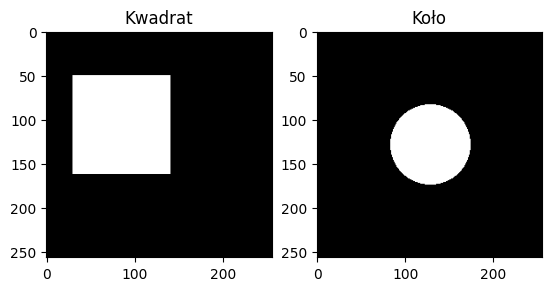

In [17]:
!wget https://raw.githubusercontent.com/vision-agh/poc_sw/master/02_Point/kwadrat.bmp
kwadrat = cv2.imread('kwadrat.bmp')

!wget https://raw.githubusercontent.com/vision-agh/poc_sw/master/02_Point/kolo.bmp
kolo = cv2.imread('kolo.bmp')

plt.subplot(1, 2, 1)
plt.imshow(kwadrat)
plt.title('Square')

plt.subplot(1, 2, 2)
plt.imshow(kolo)
plt.title('Circle')
plt.show()



Basic logic gates (NOT, AND, OR, XOR) implemented with OpenCV bitwise operators.

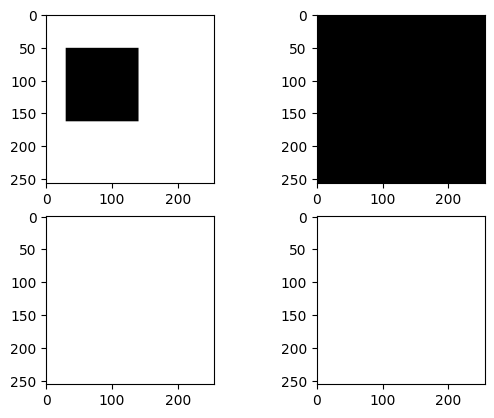

In [18]:
plt.subplot(2, 2, 1)
op1 = cv2.bitwise_not(kwadrat, kolo)
plt.imshow(op1)

plt.subplot(2, 2, 2)
op2 = cv2.bitwise_and(kwadrat, kolo)
plt.imshow(op2)

plt.subplot(2, 2, 3)
op3 = cv2.bitwise_or(kwadrat, kolo)
plt.imshow(op3)

plt.subplot(2, 2, 4)
op4 = cv2.bitwise_xor(kwadrat, kolo)
plt.imshow(op4)

plt.show()